In [9]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import japanize_matplotlib

In [31]:
data_path = "./integrated_data-Kojima_Kim_Simomura_continuous.json"

with open(data_path, "r") as f:
    data = json.load(f)

# Create a directed graph using the filtered data
G = nx.DiGraph()  # Directed graph

topic_list = set()

for entry in data:
    drill_task_name1 = entry["data"]["drill_task_name1"]
    drill_task_name2 = entry["data"]["drill_task_name2"]
    drill_task_topic1 = entry["data"]["topic1"]
    drill_task_topic2 = entry["data"]["topic2"]

    topic_list.add(drill_task_topic1)
    topic_list.add(drill_task_topic2)

    result = entry["result"]
    if drill_task_name1 not in G:
        G.add_node(drill_task_name1, topic=drill_task_topic1)
    if drill_task_name2 not in G:
        G.add_node(drill_task_name2, topic=drill_task_topic2)
    
    # Add a directed edge from drill_task_name1 to drill_task_name2 if result is "related"
    if result == "related":
        G.add_edge(drill_task_name1, drill_task_name2)

Gt = nx.transitive_reduction(G)  # Remove redundant edges

In [34]:
print("Number of nodes:", Gt.number_of_nodes())
print("Number of edges:", Gt.number_of_edges())
print("Number of topics:", len(topic_list))

Number of nodes: 23
Number of edges: 29
Number of topics: 4


In [33]:
cross_topic_edge_count = 0

for edge in Gt.edges():
    node_name1, node_name2 = edge
    node1 = G.nodes[node_name1]
    node2 = G.nodes[node_name2]
    
    if node1["topic"] != node2["topic"]:
        cross_topic_edge_count += 1

print(f"Number of cross-topic edges: {cross_topic_edge_count}")

Number of cross-topic edges: 11


In [36]:
print("The mean cross topic edge ratio is", cross_topic_edge_count / len(topic_list))

The mean cross topic edge ratio is 2.75


In [11]:
# Calculate the mean number of edges per node
mean_edges_per_node = sum(dict(G.degree()).values()) / len(G.nodes())
print(f"Mean number of edges per node: {mean_edges_per_node}")

Mean number of edges per node: 2.5217391304347827


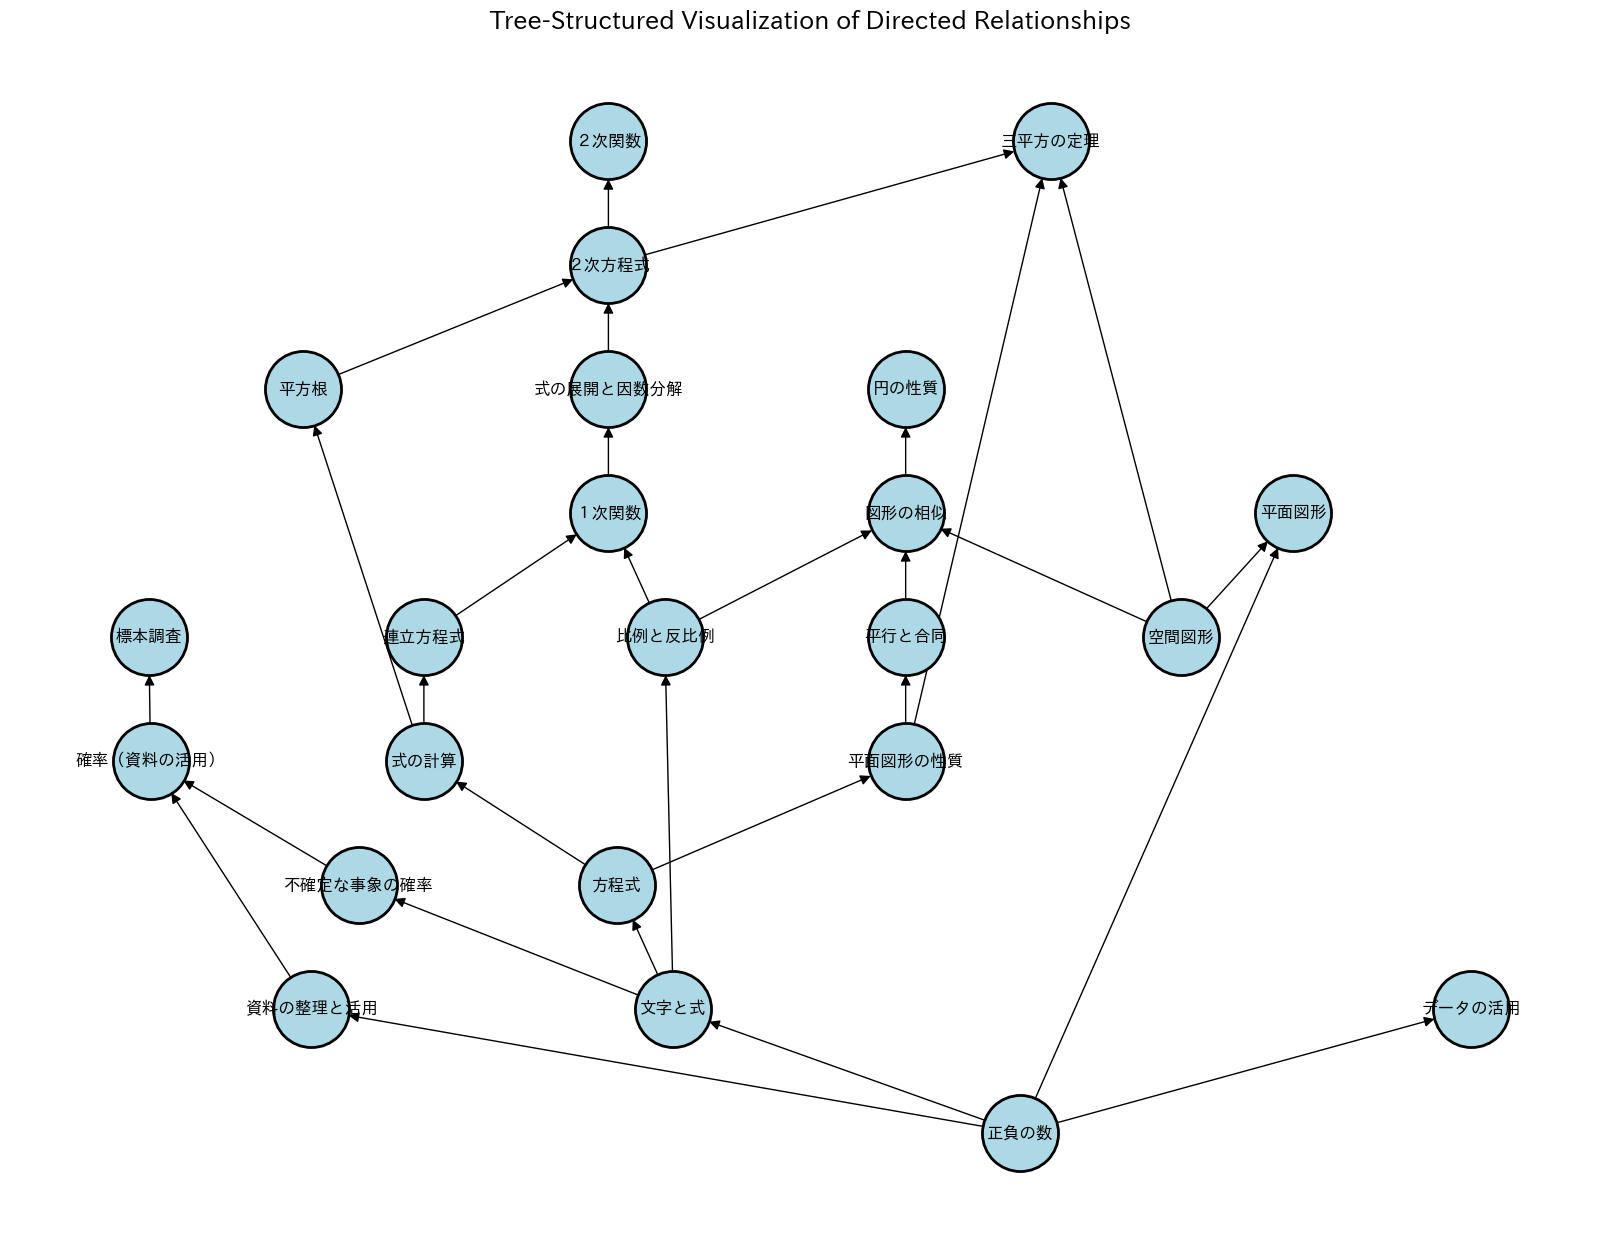

In [12]:
# Ensure the graph is a directed acyclic graph (DAG)
if not nx.is_directed_acyclic_graph(G):
    raise ValueError("The graph is not a directed acyclic graph (DAG) and cannot be visualized as a tree.")

G_reverse = G.reverse()  # Reverse the graph for topological sorting

# Use NetworkX's hierarchy layout for tree visualization
pos = nx.nx_agraph.graphviz_layout(G_reverse, prog="dot")  # 'dot' creates a hierarchical layout

# Visualize the graph as a tree
plt.figure(figsize=(16, 12))
nx.draw(
    G, pos, with_labels=True, arrows=True, arrowstyle='-|>', arrowsize=15,
    node_size=3000, node_color="lightblue", edgecolors="black", linewidths=2, font_family="IPAexGothic"
)
plt.title("Tree-Structured Visualization of Directed Relationships", fontsize=18)
plt.axis("off")
plt.show()